In [25]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Restaurant": ["Taco Town", "Burger Planet", "Pizza Paradise", "Sushi World",
                   "Taco Town", "KFC Express", "Salad Haven", "Burger Planet",
                   "Pizza Paradise", "Steak House"],

    "Inspection Date": ["2023-5-10", "2023/06/15", "15-07-2023", "2023-08-20",
                        "2023-5-10", "2023.09.01", "2023-10-12", "2023/06/15",
                        None, "missing"],

    "Hygiene Score": [85, None, 92, 47, 85, 68, 74, 61, None, 55],

    "City": ["cairo", "CAIRO", "giza", "Cairo", "cairo", "Giza", "cairo", "CAIRO", "giza", "Cairo"],

    "Violations": [2, 1, None, 5, 2, "three", 2, 1, 4, 7]
}

df = pd.DataFrame(data)
print(df.head())

       Restaurant Inspection Date  Hygiene Score   City Violations
0       Taco Town       2023-5-10           85.0  cairo          2
1   Burger Planet      2023/06/15            NaN  CAIRO          1
2  Pizza Paradise      15-07-2023           92.0   giza       None
3     Sushi World      2023-08-20           47.0  Cairo          5
4       Taco Town       2023-5-10           85.0  cairo          2


In [13]:
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant       10 non-null     object 
 1   Inspection Date  9 non-null      object 
 2   Hygiene Score    8 non-null      float64
 3   City             10 non-null     object 
 4   Violations       9 non-null      object 
dtypes: float64(1), object(4)
memory usage: 532.0+ bytes
None
Restaurant         0
Inspection Date    1
Hygiene Score      2
City               0
Violations         1
dtype: int64
1


In [24]:
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.duplicated().sum())

0
0


In [26]:
df["City"] = df["City"].str.strip().str.lower() # remove spaces and make all lowercase

In [16]:
df["Inspection Date"] = pd.to_datetime(df["Inspection Date"], errors="coerce")

In [17]:
df["Hygiene Score"] = pd.to_numeric(df["Hygiene Score"], errors="coerce")
df["Hygiene Score"] = df["Hygiene Score"].fillna(df["Hygiene Score"].median())

In [18]:
df["Violations"] = df["Violations"].replace("three", 3)
df["Violations"] = pd.to_numeric(df["Violations"], errors="coerce")
df["Violations"] = df["Violations"].fillna(0)

/tmp/ipykernel_3235/308705089.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Violations"] = df["Violations"].replace("three", 3)


In [19]:
df = df.dropna(subset=["Restaurant", "Inspection Date"])
df["Hygiene Score"] = df["Hygiene Score"].fillna(df["Hygiene Score"].median())

In [20]:
df = pd.get_dummies(df, columns=["City"])

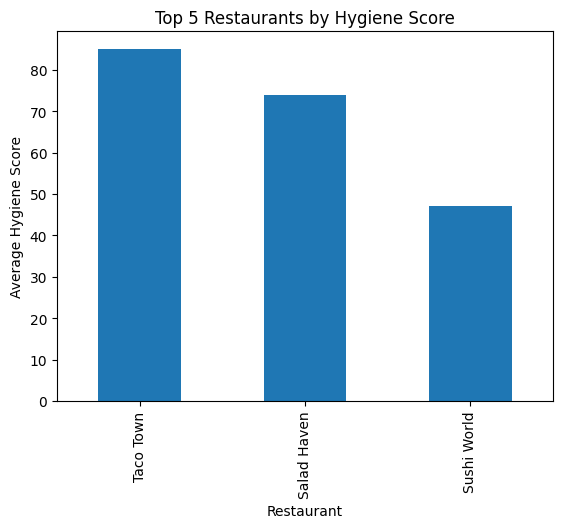

In [21]:
top_restaurants = df.groupby("Restaurant")["Hygiene Score"].mean().sort_values(ascending=False).head(5)

top_restaurants.plot(kind="bar")

plt.title("Top 5 Restaurants by Hygiene Score")
plt.xlabel("Restaurant")
plt.ylabel("Average Hygiene Score")
plt.show()